Iniciando bateria de treinamentos...


Treinando SARSA (Taxi-v3): 100%|██████████| 5000/5000 [00:06<00:00, 784.32it/s] 


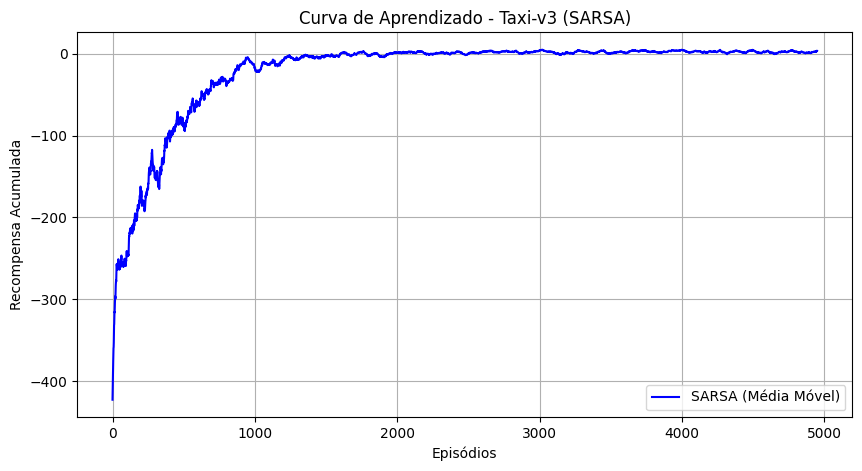

[Taxi-v3] Episódio 1 concluído: Retorno acumulado = 9.0


Treinando SARSA (CliffWalking-v1): 100%|██████████| 5000/5000 [00:03<00:00, 1412.43it/s]


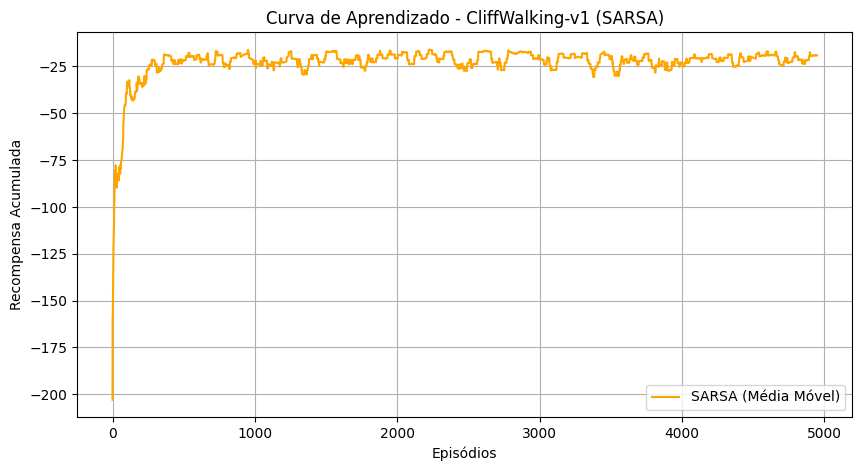

[CliffWalking-v1] Episódio 1 concluído: Retorno acumulado = -15.0

Treinamentos concluídos!


In [16]:
import numpy as np
import gymnasium as gym
from tqdm import tqdm
import matplotlib.pyplot as plt
import time
import pandas as pd
import os

class AgenteSarsa:
    def __init__(self, env_name, alpha=0.1, epsilon=0.1, gamma=0.99):
        # O env_name define se estamos no Taxi ou no CliffWalking
        self.env_name = env_name
        self.alpha = alpha
        self.epsilon = epsilon
        self.gamma = gamma

    def argmax(self, q_values):
        # Lógica genérica para encontrar a melhor ação desempatando aleatoriamente
        top_value = float('-inf')
        ties = []

        for i in range(len(q_values)):
            if q_values[i] > top_value:
                ties = []
                top_value = q_values[i]
                ties.append(i)
            elif q_values[i] == top_value:
                ties.append(i)
        
        return np.random.choice(ties)

    def greedy_action_selection(self, Q_state):
        return self.argmax(Q_state)

    def epsilon_greedy_action_selection(self, Q_state):
        # Política de exploração genérica
        if np.random.rand() < self.epsilon:
            return np.random.randint(len(Q_state))  # Explora
        else:
            return self.argmax(Q_state)  # Exploit

    def incremental_update(self, Q, state, action, reward, next_state, next_action, done):
        # Atualização Bellman exclusiva do SARSA (On-Policy)
        if done:
            target = reward
        else:
            # Usa a ação REAL que será tomada no próximo estado
            target = reward + self.gamma * Q[next_state][next_action]

        Q[state][action] = Q[state][action] + self.alpha * (target - Q[state][action])
        return Q

    def run_algorithm(self, runs=5000):
        # Função adaptável a qualquer ambiente discreto do Gym
        env = gym.make(self.env_name)
        n_states = env.observation_space.n    
        n_actions = env.action_space.n

        Q = np.zeros((n_states, n_actions), dtype=float)
        Rewards = np.zeros(runs, dtype=float)
        log_data = []

        for run in tqdm(range(runs), desc=f"Treinando SARSA ({self.env_name})"):
            obs, info = env.reset()
            action = self.epsilon_greedy_action_selection(Q[obs])
            
            total_reward = 0
            done = False

            while not done:
                next_obs, reward, terminated, truncated, info = env.step(action)
                done = terminated or truncated

                if not done:
                    next_action = self.epsilon_greedy_action_selection(Q[next_obs])
                else:
                    next_action = 0

                Q = self.incremental_update(Q, state=obs, action=action,
                                            reward=reward, next_state=next_obs, 
                                            next_action=next_action, done=done)

                total_reward += reward
                obs = next_obs
                action = next_action

            Rewards[run] = total_reward
            log_data.append({"Episodio": run + 1, "Recompensa_Acumulada": total_reward})

        env.close()

        # Salvamento dinâmico: cria os nomes dos arquivos baseados no ambiente atual
        output_dir = r"..\..\Outputs\Assignment"
        os.makedirs(output_dir, exist_ok=True)
        
        nome_arquivo_base = self.env_name.lower().replace("-", "_")
        
        pd.DataFrame(log_data).to_csv(f"{output_dir}\\log_sarsa_{nome_arquivo_base}.csv", index=False)
        np.savetxt(f"{output_dir}\\q-table-sarsa-{nome_arquivo_base}.csv", Q, delimiter=",")
        
        return Rewards, Q 
    
    def plot(self, episodic_rewards):
        # Gráfico se adapta mudando o título e o nome do arquivo salvo
        window = 50
        smoothed_rewards = np.convolve(episodic_rewards, np.ones(window)/window, mode='valid')
        
        # Define uma cor diferente dependendo do ambiente apenas para fins visuais
        cor = 'orange' if 'Cliff' in self.env_name else 'blue'
        
        plt.figure(figsize=(10, 5))
        plt.plot(smoothed_rewards, color=cor, label="SARSA (Média Móvel)")
        plt.xlabel("Episódios")
        plt.ylabel("Recompensa Acumulada")
        plt.title(f"Curva de Aprendizado - {self.env_name} (SARSA)")
        plt.legend()
        plt.grid(True)

        output_dir = r"..\..\Outputs\Assignment"

        # Cria o diretório se ele não existir
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)
        
        nome_arquivo_base = self.env_name.lower().replace("-", "_")
        plt.savefig(f"{output_dir}\\curva_sarsa_{nome_arquivo_base}.png")
        plt.show()
        
    def view(self, Q, episodes=3, max_steps=100, sleep=0.1):
        # Visualização genérica
        env = gym.make(self.env_name, render_mode="human")
        
        for ep in range(episodes):
            obs, info = env.reset()
            total = 0.0

            for _ in range(max_steps):
                action = self.greedy_action_selection(Q[obs])  
                obs, reward, terminated, truncated, info = env.step(action)
                total += reward
                time.sleep(sleep)

                if terminated or truncated:
                    break

            print(f"[{self.env_name}] Episódio {ep+1} concluído: Retorno acumulado = {total}")

        env.close()


if __name__ == "__main__":
    # Configuração inicial dada pelo professor
    alpha = 0.1
    epsilon = 0.1
    gamma = 0.99
    
    print("Iniciando bateria de treinamentos...")
    
    # ---------------------------------------------------------
    # 1. Resolvendo o ambiente do Taxi Driver
    # ---------------------------------------------------------
    agente_taxi = AgenteSarsa(env_name="Taxi-v3", alpha=alpha, epsilon=epsilon, gamma=gamma)
    recompensas_taxi, q_table_taxi = agente_taxi.run_algorithm()
    agente_taxi.plot(recompensas_taxi)
    agente_taxi.view(q_table_taxi, episodes=1) 
    
    # ---------------------------------------------------------
    # 2. Resolvendo o ambiente do Cliff Walking
    # ---------------------------------------------------------
    agente_cliff = AgenteSarsa(env_name="CliffWalking-v1", alpha=alpha, epsilon=epsilon, gamma=gamma)
    recompensas_cliff, q_table_cliff = agente_cliff.run_algorithm()
    agente_cliff.plot(recompensas_cliff)
    agente_cliff.view(q_table_cliff, episodes=1)
    
    print("\nTreinamentos concluídos!")


[INICIANDO] Treinamento no ambiente Taxi-v3...


Treinando Q_LEARNING (Taxi-v3): 100%|██████████| 5000/5000 [00:06<00:00, 801.46it/s] 


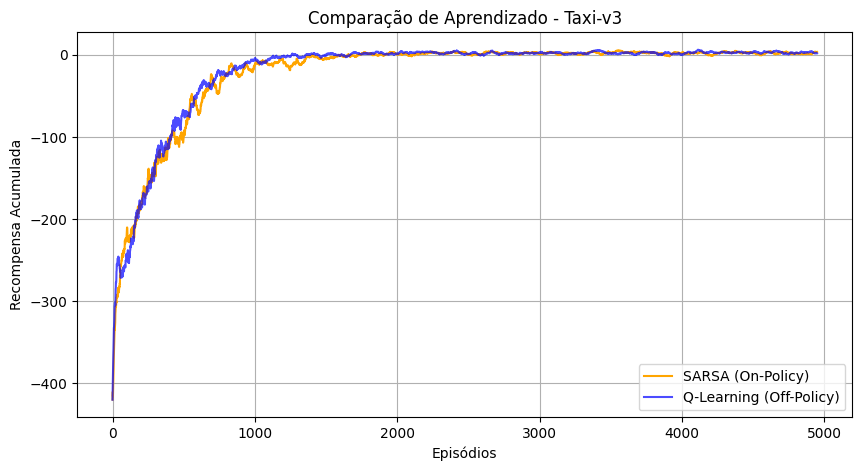


--- Validação SARSA | Taxi-v3 (100 Episódios) ---
Average actions taken: 12.89
Standard deviation actions taken: 2.5880301389280613
Average rewards: 8.11
Standard deviation rewards: 2.5880301389280613
--------------------------------------------------

--- Validação Q_LEARNING | Taxi-v3 (100 Episódios) ---
Average actions taken: 12.98
Standard deviation actions taken: 2.5297430699578958
Average rewards: 8.02
Standard deviation rewards: 2.5297430699578958
--------------------------------------------------

[INICIANDO] Treinamento no ambiente CliffWalking-v1...


Treinando Q_LEARNING (CliffWalking-v1): 100%|██████████| 5000/5000 [00:03<00:00, 1499.53it/s]


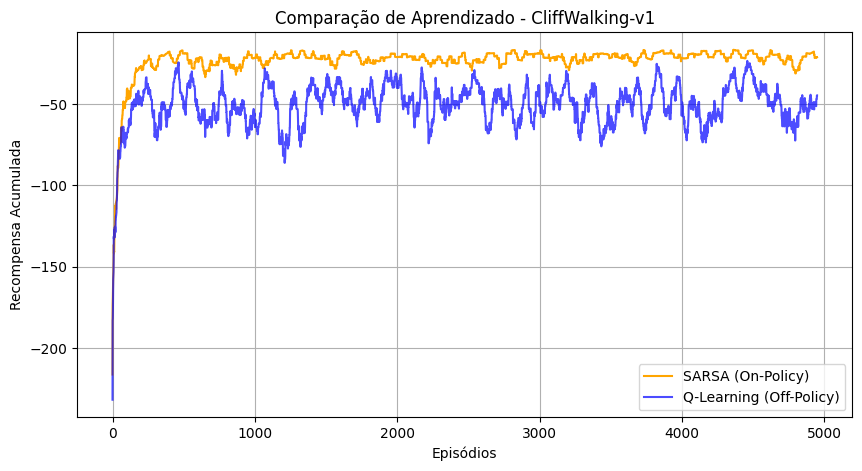


--- Validação SARSA | CliffWalking-v1 (100 Episódios) ---
Average actions taken: 15.0
Standard deviation actions taken: 0.0
Average rewards: -15.0
Standard deviation rewards: 0.0
--------------------------------------------------

--- Validação Q_LEARNING | CliffWalking-v1 (100 Episódios) ---
Average actions taken: 13.0
Standard deviation actions taken: 0.0
Average rewards: -13.0
Standard deviation rewards: 0.0
--------------------------------------------------

Execução finalizada com sucesso! Todos os dados e gráficos foram salvos.


In [18]:
import numpy as np
import gymnasium as gym
from tqdm import tqdm
import matplotlib.pyplot as plt
import time
import pandas as pd
import os

class AgenteRL:
    def __init__(self, env_name, algo="sarsa", alpha=0.1, epsilon=0.1, gamma=0.99):
        # Parâmetros principais
        self.env_name = env_name
        self.algo = algo.lower() # "sarsa" ou "q_learning"
        self.alpha = alpha
        self.epsilon = epsilon
        self.gamma = gamma

    def argmax(self, q_values):
        # Encontra a melhor ação, mas desempata aleatoriamente se houver valores iguais
        top_value = float('-inf')
        ties = []

        for i in range(len(q_values)):
            if q_values[i] > top_value:
                ties = []
                top_value = q_values[i]
                ties.append(i)
            elif q_values[i] == top_value:
                ties.append(i)
        
        return np.random.choice(ties)

    def greedy_action_selection(self, Q_state):
        return self.argmax(Q_state)

    def epsilon_greedy_action_selection(self, Q_state):
        # Política de exploração vs aproveitamento (Exploration vs Exploitation)
        if np.random.rand() < self.epsilon:
            return np.random.randint(len(Q_state))  # Explora
        else:
            return self.argmax(Q_state)  # Exploit

    def incremental_update(self, Q, state, action, reward, next_state, next_action, done):

        # AQUI FICA A GRANDE DIFERENÇA ENTRE OS ALGORITMOS
        if done:
            target = reward
        else:
            if self.algo == "sarsa":
                # SARSA (On-Policy): Usa o valor da próxima ação real
                target = reward + self.gamma * Q[next_state][next_action]
            elif self.algo == "q_learning":
                # Q-Learning (Off-Policy): Usa o valor máximo do próximo estado
                target = reward + self.gamma * np.max(Q[next_state])
            else:
                raise ValueError("Algoritmo não reconhecido. Use 'sarsa' ou 'q_learning'.")

        # Atualização Bellman
        Q[state][action] = Q[state][action] + self.alpha * (target - Q[state][action])
        return Q

    def run_algorithm(self, runs=5000):
        env = gym.make(self.env_name)
        n_states = env.observation_space.n    
        n_actions = env.action_space.n

        # Inicializa a Q-table
        Q = np.zeros((n_states, n_actions), dtype=float)
        Rewards = np.zeros(runs, dtype=float)
        log_data = []

        for run in tqdm(range(runs), desc=f"Treinando {self.algo.upper()} ({self.env_name})"):
            obs, info = env.reset()
            
            # Escolhe a ação inicial
            action = self.epsilon_greedy_action_selection(Q[obs])
            total_reward = 0
            done = False

            while not done:
                next_obs, reward, terminated, truncated, info = env.step(action)
                done = terminated or truncated

                # Define a próxima ação do próximo estado (mesmo que Q-Learning não use na conta, 
                # precisamos dela para dar o step na próxima iteração do loop)
                if not done:
                    next_action = self.epsilon_greedy_action_selection(Q[next_obs])
                else:
                    next_action = 0

                # Atualiza os valores
                Q = self.incremental_update(Q, state=obs, action=action,
                                            reward=reward, next_state=next_obs, 
                                            next_action=next_action, done=done)

                total_reward += reward
                obs = next_obs
                action = next_action

            Rewards[run] = total_reward
            log_data.append({"Episodio": run + 1, "Recompensa_Acumulada": total_reward})

        env.close()

        # Salvamento automático e organizado
        output_dir = r"..\..\Outputs\Assignment"
        os.makedirs(output_dir, exist_ok=True)
        
        nome_arquivo_base = self.env_name.lower().replace("-", "_")
        
        # Salva o CSV com o nome do algoritmo para não sobrescrever
        pd.DataFrame(log_data).to_csv(f"{output_dir}\\log_{self.algo}_{nome_arquivo_base}.csv", index=False)
        np.savetxt(f"{output_dir}\\q-table-{self.algo}-{nome_arquivo_base}.csv", Q, delimiter=",")
        
        return Rewards, Q 
        
    def view(self, Q, episodes=3, max_steps=100, sleep=0.1):
        # Visualização de ambos os algoritmos
        env = gym.make(self.env_name, render_mode="human")
        
        for ep in range(episodes):
            obs, info = env.reset()
            total = 0.0

            for _ in range(max_steps):
                action = self.greedy_action_selection(Q[obs])  
                obs, reward, terminated, truncated, info = env.step(action)
                total += reward
                time.sleep(sleep)

                if terminated or truncated:
                    break

            print(f"[{self.algo.upper()} | {self.env_name}] Episódio {ep+1} concluído: Retorno acumulado = {total}")

        env.close()

    def plot(self, episodic_rewards):
        # Gráfico se adapta mudando o título e o nome do arquivo salvo
        window = 50
        smoothed_rewards = np.convolve(episodic_rewards, np.ones(window)/window, mode='valid')
        
        # Define uma cor diferente dependendo do ambiente apenas para fins visuais
        cor = 'orange' if 'Cliff' in self.env_name else 'blue'
        
        plt.figure(figsize=(10, 5))
        plt.plot(smoothed_rewards, color=cor, label="SARSA (Média Móvel)")
        plt.xlabel("Episódios")
        plt.ylabel("Recompensa Acumulada")
        plt.title(f"Curva de Aprendizado - {self.env_name} (SARSA)")
        plt.legend()
        plt.grid(True)

        output_dir = r"..\..\Outputs\Assignment"

        # Cria o diretório se ele não existir
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)
        
        nome_arquivo_base = self.env_name.lower().replace("-", "_")
        plt.savefig(f"{output_dir}\\curva_sarsa_{nome_arquivo_base}.png")
        plt.show()

    def evaluate(self, Q, episodes=100):
            # Validação robusta solicitada pelo professor
            env = gym.make(self.env_name)
            list_actions = []
            list_rewards = []
            
            for i in range(episodes):
                state, _ = env.reset()
                rewards = 0
                actions = 0
                done = False
                
                while not done:
                    # print(state) # Deixei comentado para não floodar seu terminal com 1500 linhas
                    
                    # Na validação, usamos a política gulosa (equivalente ao np.argmax do professor)
                    action = self.greedy_action_selection(Q[state])
                    state, reward, terminated, truncated, info = env.step(action)
                    done = terminated or truncated
                    
                    rewards += reward
                    actions += 1
                    
                list_actions.append(actions)
                list_rewards.append(rewards)
                
            env.close()
            
            print(f"\n--- Validação {self.algo.upper()} | {self.env_name} ({episodes} Episódios) ---")
            print("Average actions taken: {}".format(np.mean(list_actions)))
            print("Standard deviation actions taken: {}".format(np.std(list_actions)))
            print("Average rewards: {}".format(np.mean(list_rewards)))
            print("Standard deviation rewards: {}".format(np.std(list_rewards)))
            print("-" * 50)
            
            return list_actions, list_rewards


# Função auxiliar para plotar a comparação
def plot_comparacao(rewards_sarsa, rewards_qlearning, env_name):
    window = 50
    smoothed_sarsa = np.convolve(rewards_sarsa, np.ones(window)/window, mode='valid')
    smoothed_ql = np.convolve(rewards_qlearning, np.ones(window)/window, mode='valid')
    
    plt.figure(figsize=(10, 5))
    plt.plot(smoothed_sarsa, color='orange', label="SARSA (On-Policy)")
    plt.plot(smoothed_ql, color='blue', alpha=0.7, label="Q-Learning (Off-Policy)")
    plt.xlabel("Episódios")
    plt.ylabel("Recompensa Acumulada")
    plt.title(f"Comparação de Aprendizado - {env_name}")
    plt.legend()
    plt.grid(True)

    output_dir = r"..\..\Outputs\Assignment"
    os.makedirs(output_dir, exist_ok=True)
    
    nome_arquivo = env_name.lower().replace("-", "_")
    plt.savefig(f"{output_dir}\\comparacao_{nome_arquivo}.png")
    plt.show()

if __name__ == "__main__":
    # Parâmetros
    alpha = 0.1
    epsilon = 0.1
    gamma = 0.99
    
    # ==========================================
    # 1. Testes e Validação no Taxi-v3
    # ==========================================
    print("\n[INICIANDO] Treinamento no ambiente Taxi-v3...")
    taxi_sarsa = AgenteRL("Taxi-v3", algo="sarsa", alpha=alpha, epsilon=epsilon, gamma=gamma)
    taxi_ql = AgenteRL("Taxi-v3", algo="q_learning", alpha=alpha, epsilon=epsilon, gamma=gamma)
    
    recompensas_taxi_sarsa, q_taxi_sarsa = taxi_sarsa.run_algorithm()
    recompensas_taxi_ql, q_taxi_ql = taxi_ql.run_algorithm()
    
    # Plota e salva a comparação
    plot_comparacao(recompensas_taxi_sarsa, recompensas_taxi_ql, "Taxi-v3")
    
    # Executa a validação robusta (100 episódios)
    taxi_sarsa.evaluate(q_taxi_sarsa, episodes=100)
    taxi_ql.evaluate(q_taxi_ql, episodes=100)
    
    # ==========================================
    # 2. Testes e Validação no CliffWalking-v1
    # ==========================================
    print("\n[INICIANDO] Treinamento no ambiente CliffWalking-v1...")
    cliff_sarsa = AgenteRL("CliffWalking-v1", algo="sarsa", alpha=alpha, epsilon=epsilon, gamma=gamma)
    cliff_ql = AgenteRL("CliffWalking-v1", algo="q_learning", alpha=alpha, epsilon=epsilon, gamma=gamma)
    
    recompensas_cliff_sarsa, q_cliff_sarsa = cliff_sarsa.run_algorithm()
    recompensas_cliff_ql, q_cliff_ql = cliff_ql.run_algorithm()
    
    # Plota e salva a comparação
    plot_comparacao(recompensas_cliff_sarsa, recompensas_cliff_ql, "CliffWalking-v1")
    
    # Executa a validação robusta (100 episódios)
    cliff_sarsa.evaluate(q_cliff_sarsa, episodes=100)
    cliff_ql.evaluate(q_cliff_ql, episodes=100)
    
    print("\nExecução finalizada com sucesso! Todos os dados e gráficos foram salvos.")